# MedMNIST analysis
Vérification rapide : 2 exemples (224x224 natif) pour chaque dataset 2D utilisé.

In [1]:
import os
import matplotlib.pyplot as plt
import medmnist
from medmnist import INFO

ROOT = os.path.expanduser("~/.medmnist")
SIZE = 224
N_PER = 2

STAGE_1 = ["pathmnist", "dermamnist", "pneumoniamnist", "bloodmnist", "organcmnist", "organsmnist"]
STAGE_2 = ["chestmnist", "octmnist", "retinamnist", "breastmnist", "tissuemnist", "organamnist"]
DATASETS = STAGE_1 + STAGE_2

KeyboardInterrupt: 

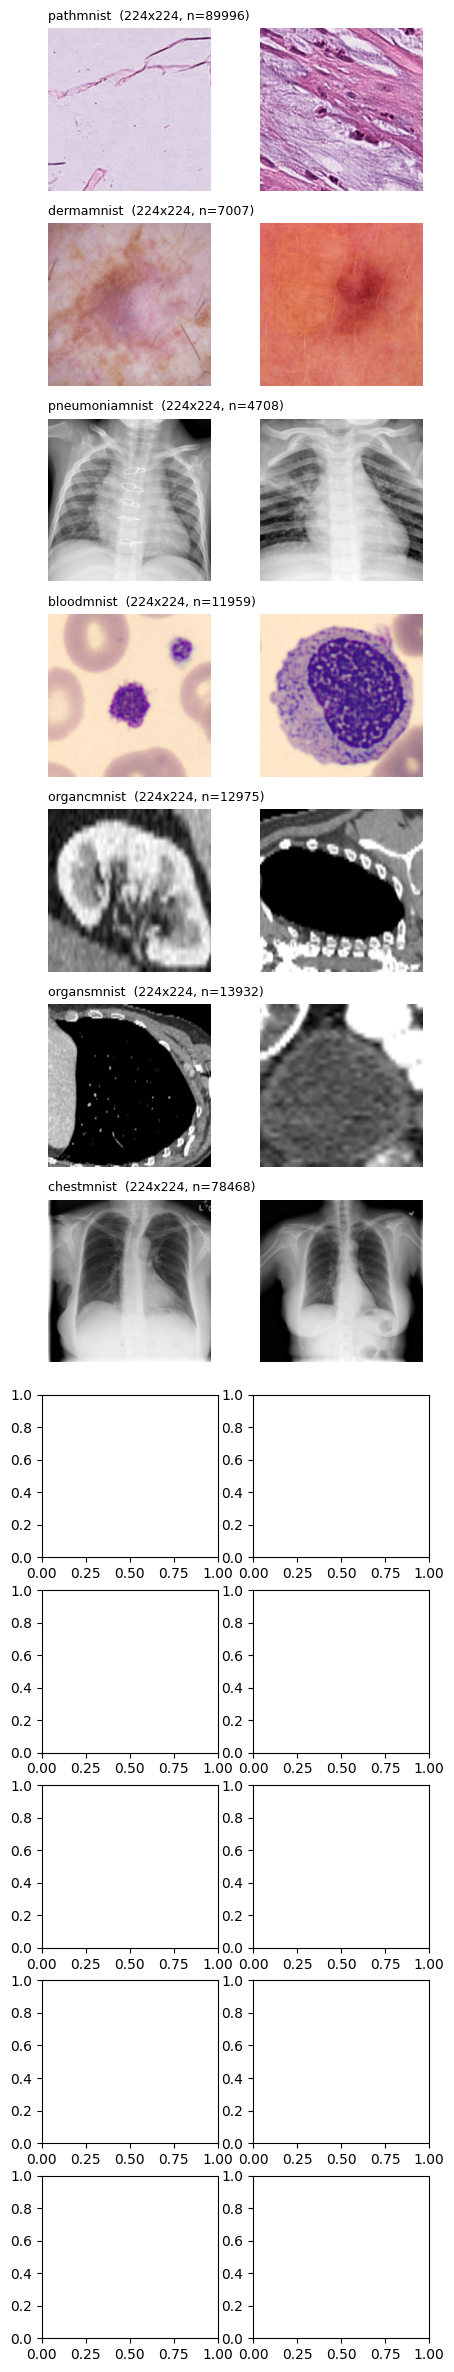

In [2]:
fig, axes = plt.subplots(len(DATASETS), N_PER, figsize=(N_PER * 2.5, len(DATASETS) * 2.5))

for row, name in enumerate(DATASETS):
    cls = getattr(medmnist, INFO[name]["python_class"])
    try:
        ds = cls(split="train", download=True, root=ROOT, size=SIZE)
    except Exception as e:
        print(f"skip {name}: {e}")
        for col in range(N_PER):
            axes[row, col].axis("off")
        continue

    h, w = ds.imgs.shape[1], ds.imgs.shape[2]
    for col in range(N_PER):
        img, _ = ds[col]
        ax = axes[row, col]
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(f"{name}  ({h}x{w}, n={len(ds)})", loc="left", fontsize=9)

plt.tight_layout()
plt.show()